In [1]:
import numpy as np
import matplotlib.pyplot as plt

from collections import namedtuple

from matplotlib.patches import Polygon
import ipywidgets as widgets

In [2]:
def Rxy(alpha, beta):
    """Матрица поворота вокруг осей Oy и Ox.
    Реализовать самостоятельно или заменить на функции из библиотеки scipy.spatial"""
    pass

# Этого файла у вас не будет, вам надо функцию выше реализовать самостоятельно
# а эту строку убрать
from rxy import Rxy

projector = np.diag([1, 1, 0])

In [3]:
Polyhedron = namedtuple(typename='Polyhedron', field_names=('vertices', 'faces'))

In [30]:
# Углы поворота в градусах
α = 47
β = 24

In [19]:
cube = Polyhedron(
    vertices=np.array([
        [0, 0, 0], # 0
        [0, 1, 0], # 1
        [1, 1, 0], # 2
        [1, 0, 0], # 3
        [0, 0, 1], # 4
        [0, 1, 1], # 5
        [1, 1, 1], # 6
        [1, 0, 1], # 7
    ]),
    faces=[
        [0, 4, 5, 1], # 0
        [0, 3, 7, 4], # 1
        [3, 2, 6, 7], # 2
        [2, 1, 5, 6], # 3
        [0, 1, 2, 3], # 4
        [6, 5, 4, 7], # 5
    ]
)

In [20]:
cube.vertices[cube.faces[1]]

array([[0, 0, 0],
       [1, 0, 0],
       [1, 0, 1],
       [0, 0, 1]])

In [21]:
for (i, face) in enumerate(cube.faces):
    print(f"Грань {i}: {face}")
    for (face_idx, vertex) in zip(face, cube.vertices[face]):
        print(f"  Вершина №{face_idx} с координатами {vertex}")

Грань 0: [0, 4, 5, 1]
  Вершина №0 с координатами [0 0 0]
  Вершина №4 с координатами [0 0 1]
  Вершина №5 с координатами [0 1 1]
  Вершина №1 с координатами [0 1 0]
Грань 1: [0, 3, 7, 4]
  Вершина №0 с координатами [0 0 0]
  Вершина №3 с координатами [1 0 0]
  Вершина №7 с координатами [1 0 1]
  Вершина №4 с координатами [0 0 1]
Грань 2: [3, 2, 6, 7]
  Вершина №3 с координатами [1 0 0]
  Вершина №2 с координатами [1 1 0]
  Вершина №6 с координатами [1 1 1]
  Вершина №7 с координатами [1 0 1]
Грань 3: [2, 1, 5, 6]
  Вершина №2 с координатами [1 1 0]
  Вершина №1 с координатами [0 1 0]
  Вершина №5 с координатами [0 1 1]
  Вершина №6 с координатами [1 1 1]
Грань 4: [0, 1, 2, 3]
  Вершина №0 с координатами [0 0 0]
  Вершина №1 с координатами [0 1 0]
  Вершина №2 с координатами [1 1 0]
  Вершина №3 с координатами [1 0 0]
Грань 5: [6, 5, 4, 7]
  Вершина №6 с координатами [1 1 1]
  Вершина №5 с координатами [0 1 1]
  Вершина №4 с координатами [0 0 1]
  Вершина №7 с координатами [1 0 1]


In [31]:
# Вращаем координаты вершин
transformed_vertices = np.transpose(projector @ Rxy(α, β) @ cube.vertices.T)
transformed_vertices

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.91354546,  0.        ],
       [ 0.68199836,  1.21101381,  0.        ],
       [ 0.68199836,  0.29746835,  0.        ],
       [ 0.7313537 , -0.27739372,  0.        ],
       [ 0.7313537 ,  0.63615173,  0.        ],
       [ 1.41335206,  0.93362008,  0.        ],
       [ 1.41335206,  0.02007463,  0.        ]])

In [32]:
# Достаем все x и y вершин одной грани
X, Y, Z = transformed_vertices[cube.faces[0]].T

In [33]:
X, Y, Z

(array([0.       , 0.7313537, 0.7313537, 0.       ]),
 array([ 0.        , -0.27739372,  0.63615173,  0.91354546]),
 array([0., 0., 0., 0.]))

In [34]:
transformed_vertices[cube.faces[0]]

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.7313537 , -0.27739372,  0.        ],
       [ 0.7313537 ,  0.63615173,  0.        ],
       [ 0.        ,  0.91354546,  0.        ]])

In [35]:
# Координаты x и y вершин
transformed_vertices[cube.faces[0]][:, 0:2] # 2 не входит в диапазон [0, 2)

array([[ 0.        ,  0.        ],
       [ 0.7313537 , -0.27739372],
       [ 0.7313537 ,  0.63615173],
       [ 0.        ,  0.91354546]])

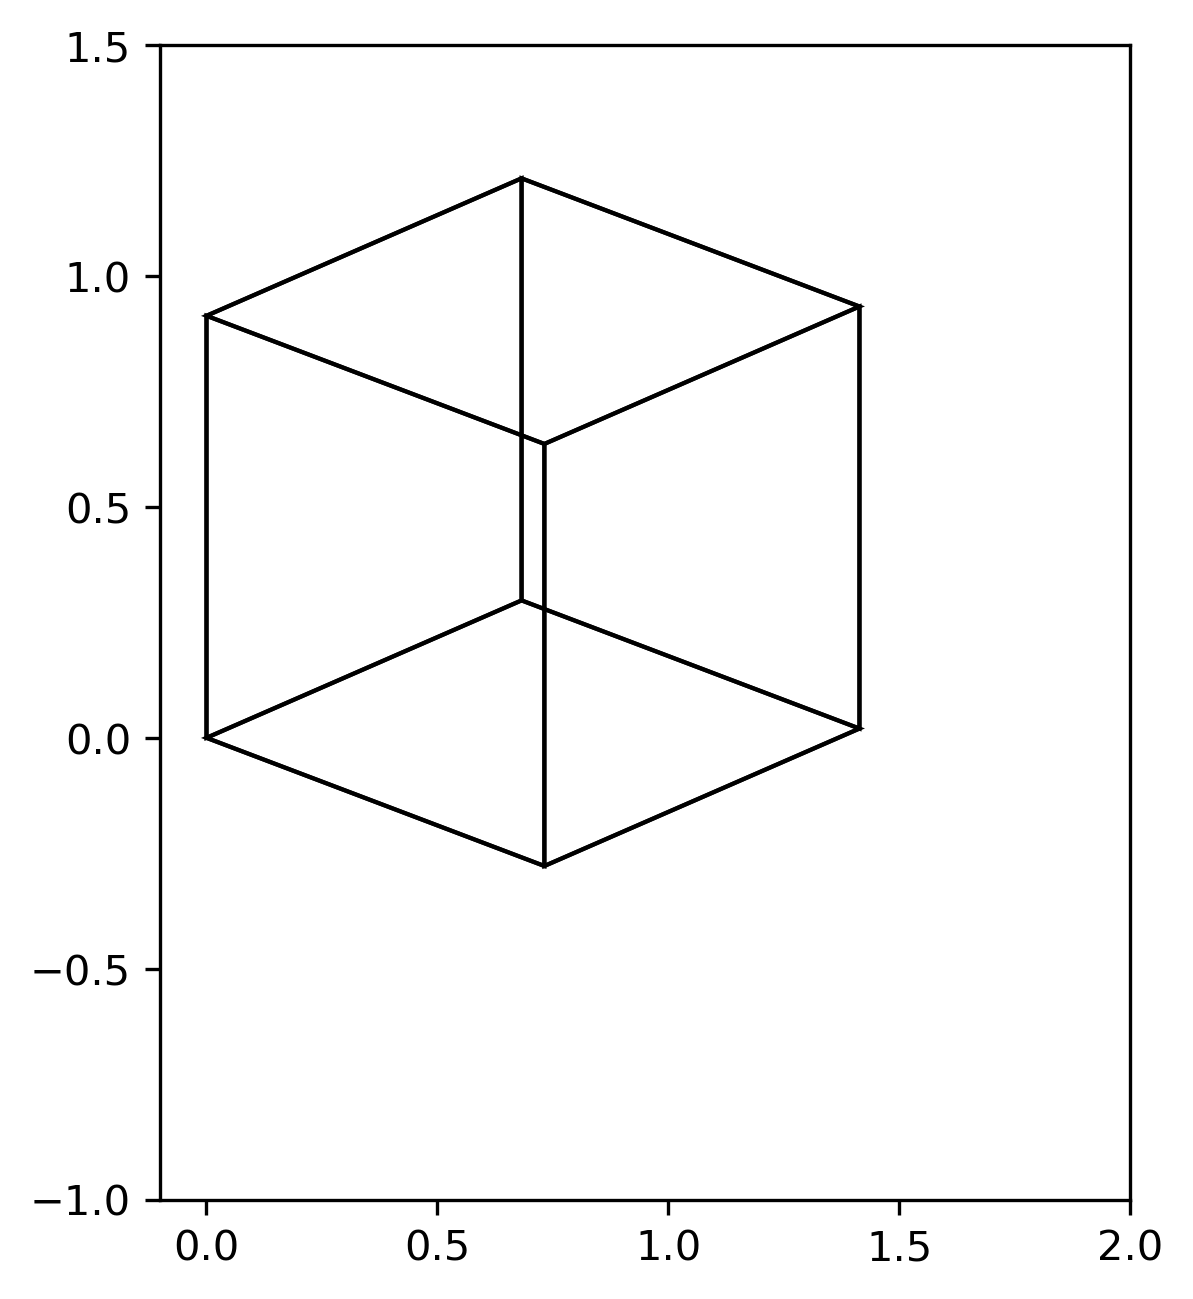

In [37]:
fig = plt.figure(num=1, figsize=(5, 5), dpi=300)
ax01 = fig.add_subplot(1, 1, 1)

ax01.set_xlim(left=-0.1, right=2)
ax01.set_ylim(top=1.5, bottom=-1)

ax01.set_aspect('equal')

# for face in cube.faces:
#     X, Y, Z = transformed_vertices[face].T
#     ax01.plot(X, Y, color='k')

# То же самое, но не в цикле
# X, Y, Z = transformed_vertices[cube.faces[0]].T
# ax01.plot(X, Y, color='k')
# X, Y, Z = transformed_vertices[cube.faces[1]].T
# ax01.plot(X, Y, color='k')
# X, Y, Z = transformed_vertices[cube.faces[2]].T
# ax01.plot(X, Y, color='k')
# X, Y, Z = transformed_vertices[cube.faces[3]].T
# ax01.plot(X, Y, color='k')
# X, Y, Z = transformed_vertices[cube.faces[4]].T
# ax01.plot(X, Y, color='k')

for face in cube.faces:
    polygon = Polygon(
        xy=transformed_vertices[face][:, 0:2],
        closed=True,
        fill=False,
        edgecolor='black')
    ax01.add_patch(polygon)